# E00: Quotient geometry and scale invariance

**Article:** *Scale-Invariant Vector-Valued Wasserstein Quotient Geometry for Inverse Problems*.

**Default behavior: actual computation, not replay of reference arrays.** Run **all cells** in order from a clean clone with dependencies installed via `python -m pip install -e ".[notebooks,test,thirdparty]"`. The notebooks call the current numerical source modules and produce experiment datasets only when executed. Heavy inversions can take substantial time; E02/E03/E05 retrieve the pinned Sambridge baseline source from the original authors’ GitHub archive when first needed and cache it outside this repository; see README for source attribution, network requirements and offline instructions. Saved outputs document previous real executions. Restarting the kernel and running all cells recomputes the experiment; no precomputed result files are supplied.

In [1]:
from pathlib import Path
import os, sys, subprocess
from IPython.display import display, Image
ROOT = Path.cwd().resolve()
for candidate in (ROOT,*ROOT.parents):
    if (candidate/'pyproject.toml').is_file() and (candidate/'qvvw2'/'core.py').is_file():
        ROOT=candidate;break
else:
    raise RuntimeError('Start Jupyter from the extracted qvvw2 repository root, or place this notebook under notebooks/.')
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import qvvw2
from scripts.prepare_fresh_plot_data import prepare
from scripts.make_paper_figures import render_selected
print('Repository:',ROOT.name)
print('Python version:',sys.version.split()[0])
print('Q-vvW2 loaded from current repository:',Path(qvvw2.__file__).resolve().is_relative_to(ROOT))
assert Path(qvvw2.__file__).resolve().is_relative_to(ROOT), 'Wrong installed qvvw2 package; run pip install -e .'
def run(*args):
    cmd=[sys.executable,'-u',*map(str,args)]
    print('RUN: python -u', ' '.join(map(str,args)),flush=True)
    proc=subprocess.Popen(cmd, cwd=ROOT, stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,bufsize=1)
    for line in proc.stdout: print(line,end='',flush=True)
    code=proc.wait()
    if code:raise RuntimeError(f'Failed (exit {code}): {cmd}')
def show(numbers):
    for p in render_selected(numbers):
        print('Generated:',p.relative_to(ROOT))
        display(Image(filename=str(p)))


Repository: qvvw2
Python version: 3.13.5
Q-vvW2 loaded from current repository: True


## Generate new numerical results from scratch

No frozen CSV/NPY/NPZ datasets are loaded. The commands below run the original current experiments and print progress. On failure, the Notebook stops with an exception rather than silently reusing an archived output.

In [2]:
run('-m', 'experiments.E00.code.run_e00')

RUN: python -u -m experiments.E00.code.run_e00


[E00] Starting quotient-geometry experiment


[E00] Evaluating positive-scale orbit on 61 scales


[E00] Numerical gates complete; generating Fig. 1


{


...

    0.0,


    6.081712546878795e-30,


    2.5609064735378635e-30


  ]


}


## Plot newly generated paper figures

First verify fresh results exist and copy them into a local plotting directory (ignored by Git). Plotting code reads only that directory. Generated images are displayed directly below.

Figure 1 generated from fresh-run inputs


Generated: .qvvw2_generated/paper_figures/figure01.png


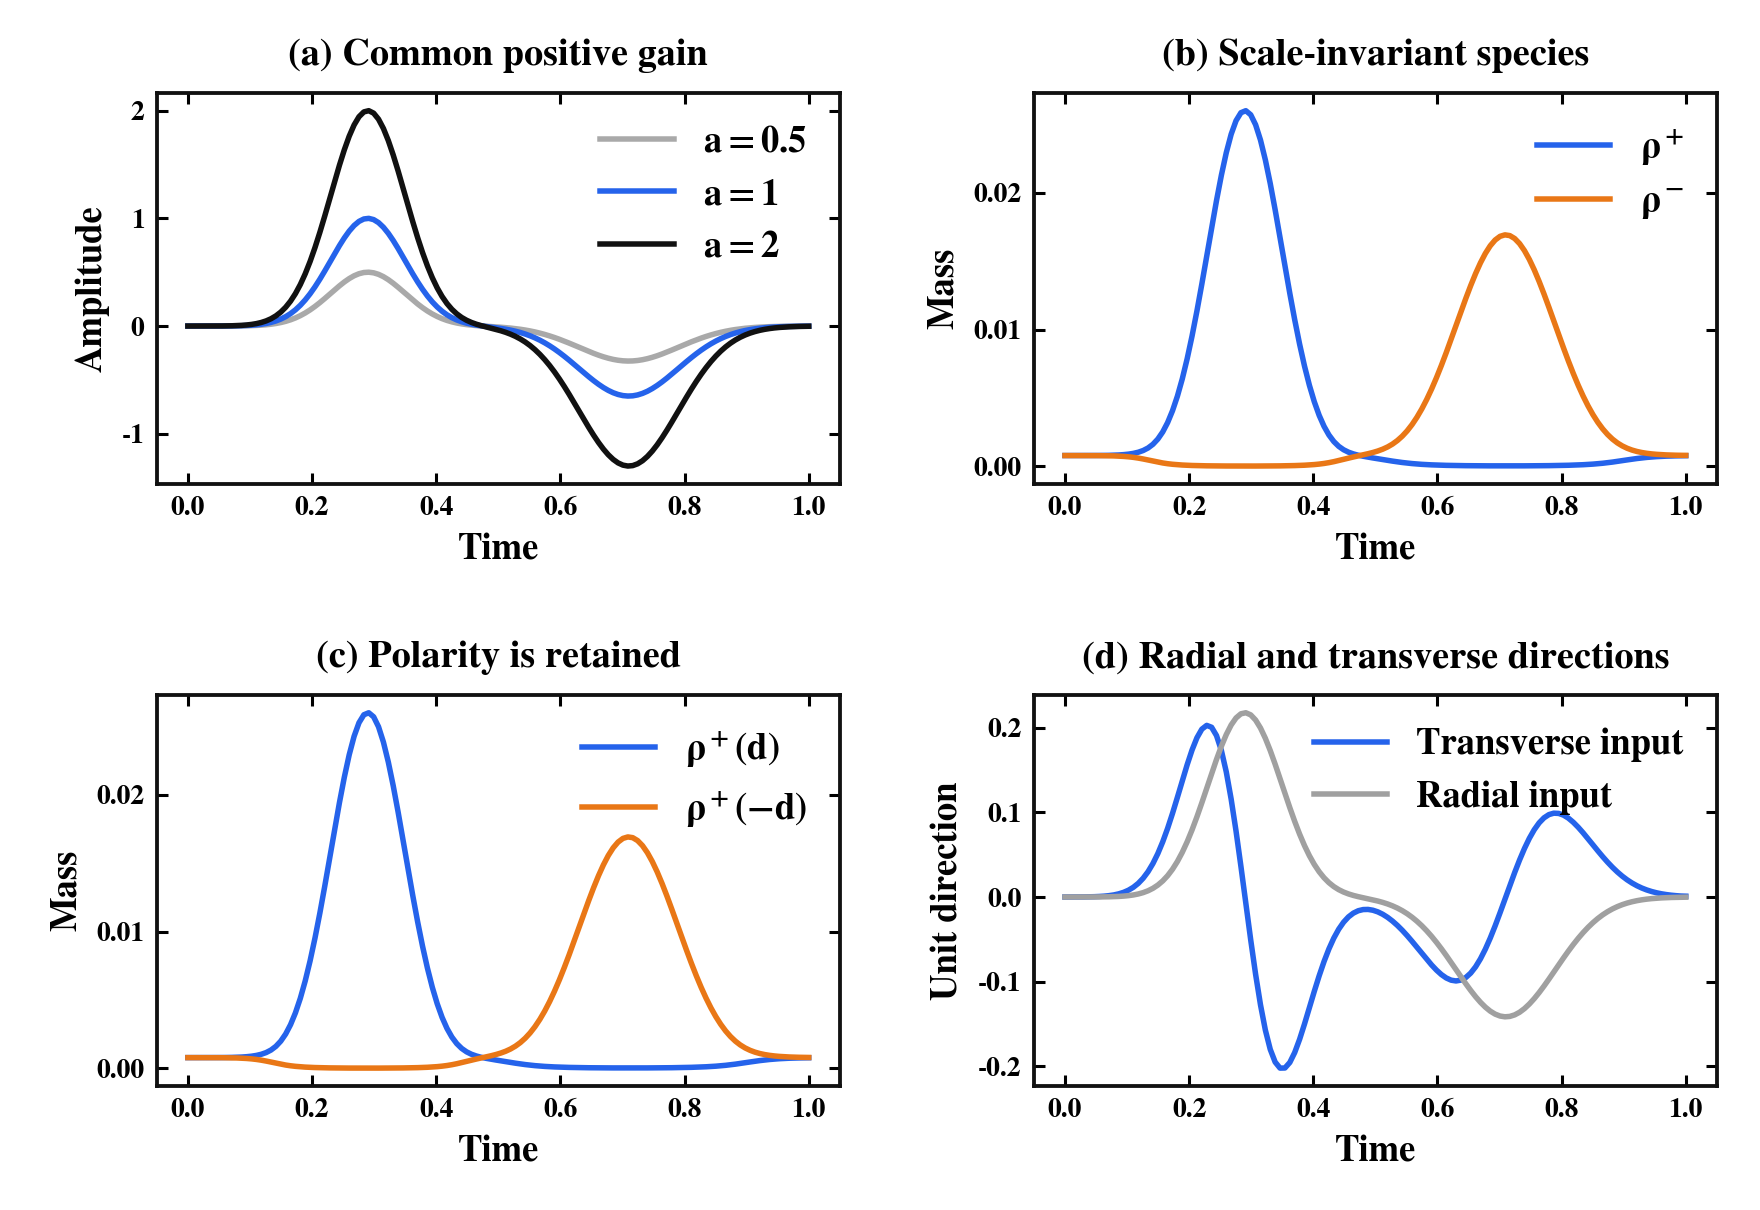

In [3]:
prepare('E00')
show([1])